In [1]:
import numpy as np
import yaml
import os
from classy import Class
import matplotlib.pyplot as plt
from pybird_w0wa.correlator import Correlator
from pybird_master.correlator import Correlator as master_Correlator

# from pybird import common as co
# from pybird.likelihood import Likelihood
# from pybird.io_pb import ReadWrite


# config settings

In [2]:
# the EOS
#w = [-1.6,-0.7]
w = [-1.6,-1.,-0.7,-0.45,-3.]#np.linspace(-2,-0.4,4)
w0 = w#[-1.2,-1.,-0.7,-0.45]
wa = [-1.8,-1.2,-0.8,-0.2]
#wa = [-1.2,-0.2]
#alist=[0.6,1/(1+0.1)]
#zlist = [1/alist[i]-1 for i in range(len(alist))]
zlist = [0.32,0.57]
#zlist= [0.32]
alist = [1/(1.+z) for z in zlist]
print('redshift=',zlist,alist)

redshift= [0.32, 0.57] [0.7575757575757576, 0.6369426751592357]


In [3]:
km=0.7
paperbias={'b1':2.4,'b2':-0.4,'b3':2.1,'b4':0,'cct':0,'cr1':-8.6*km**2,'cr2':0,
           'ce0':1.4,'ce1':-4.3*km**2,'ce2':0}  # https://arxiv.org/pdf/2005.04805 fig3
guessbias = {'b1':2.,'b2':1.,'b4':1,'Bb1':2,'Bb2':1.,'Bb5':1.}
# minibias={'b1': 2.0417, 'Bb2': 1.7411, 'Bb5': 0.6181, 'Bb3': 1.8072, 
#       'Bc1': 5.0697, 'Bc2': -1.5640, 'Bc3': 1.1729, 
#       'Be1': 0.0475, 'Be2': 3.0114, 'ce2': -1.4731, 
#       'Bb4': 0.1639, 'Bb6': 0.9556, 'Bb7': 0.3585, 'Bb8': -0.4802, 'Bb9': 0.2262, 'Bb10': -2.1871, 'Bb11': -1.7619, 
#       'Bc4': -0.1628, 'Bc5': -0.3192, 'Bc6': 1.4350, 'Bc7': 0.7985, 'Bc8': 0.4208, 'Bc9': 0.2500, 'Bc10': 0.2752, 'Bc11': 0.9740, 'Bc12': 0.2877, 'Bc13': 0.0925, 'Bc14': 1.1125, 
#       'Bd1': 0.1716, 'Bd2': 1.4660, 'Bd3': -0.0000, 'Be3': 0.0775, 'Be4': -0.0157, 'Be5': 0.6205, 'Be6': -0.4740, 'Be7': -0.4299, 'Be8': 0.3059, 'Be9': 0.2075, 'Be10': 0.2194, 'Be11': 0.1628, 'Be12': 0.0898, 'cr4': 0.0000, 'cr6': 0.0000, 
#       'Bb1': 2.0417, 'b2': 1.7411, 'b3': -5.3962, 'b4': 0.6181, 
#          'cct': -5.0697, 'cr1': -1.1709, 'cr2': -0.3571, 'ce0': 0.0475, 'ce1': 2.2749}
bestbias={'b1': 1.9542, 'c2': 0.5904, 'c4': 0.0, 'b3': -0.3687, 'cct': 0.1825, 'cr1': -0.8476, 'cr2': -0.8134, 'ce0': 1.4985, 'ce1': 0.0, 'ce2': -1.6364, 'b2': 0.4175, 'b4': 0.4175}

In [4]:
def get_cosmo_at_z(z,w0,wa=0):
    M = Class()
    cosmo1 = {'omega_b': 0.02235, 'omega_cdm': 0.120, 'h': 0.675, 'ln10^{10}A_s': 3.044, 'n_s': 0.965}
    if w0 is not None:
        cosmo1.update({'Omega_Lambda':0,
              'w0_fld':w0,
            'wa_fld':wa})
    M.set(cosmo1)
    M.set({'output': 'mPk', 'P_k_max_h/Mpc': 10, 'z_max_pk': z})
    M.compute()
    kk = np.logspace(-5, 0, 200)
    pk_lin = np.array([M.pk_lin(k*M.h(), z)*M.h()**3 for k in kk]) 
    D1, f1 = M.scale_independent_growth_factor(z), M.scale_independent_growth_factor_f(z)
    return M,kk,pk_lin,D1,f1

In [5]:

def get_spectrum(setting_dict,z,eft_params,test_master=False,Eds=False,w0_fld=-1.,wa_fld=0.,with_quintessence=False):
    M,kk,pk_lin,D1,f1 = get_cosmo_at_z(z,w0_fld,wa_fld)
    setting_dict['z']=z
    if Eds:
        setting_dict['with_exact_time']=False
    else:
        setting_dict['with_exact_time']=True
        
    setting_dict['with_quintessence']=with_quintessence

    if test_master:
        N = master_Correlator()
    else:
        N = Correlator()
    N.set(setting_dict)
    #cosmo = {'omega_b': 0.02235, 'omega_cdm': 0.120, 'h': 0.675, 'ln10^{10}A_s': 3.044, 'n_s': 0.965}

    # if test_master:
    #     N.compute({'w0_fld':w0_fld},cosmo_module='class',cosmo_engine=M)
    # else:
    #     N.compute({'w0_fld':w0_fld,'wa_fld':wa_fld},cosmo_module='class',cosmo_engine=M)
    N.compute({'w0_fld':w0_fld,'wa_fld':wa_fld},cosmo_module='class',cosmo_engine=M)

    spectrum_full=N.get(eft_params,what='full')
    
    return spectrum_full



In [6]:
def get_triangle_shape(tridata):
    kf = tridata['kf']
    tn = tridata['tn']
    tri = tn*kf
    n1,n2,n3 = tn
    k1,k2,k3 = tri
    zero_area = np.argwhere((n1 == n2 + n3))[:, 0]
    equilateral = np.argwhere((n1 == n2) & (n1 == n3))[:, 0]
    isoceles = np.argwhere(((n1 != n2) & (n2 == n3)) | ((n1 == n2) & (n2 != n3)))[:, 0]
    scalene = np.argwhere((n1 != n2) & (n1 != n3) & (n2 != n3))[:, 0]
    return equilateral,isoceles,scalene

In [7]:
dk, ds = 0.01, 5
kd = np.arange(0.005, 0.3, dk)
sd = np.arange(10, 200, ds)
ps_master={
    'output': 'bPk', 'multipole': 2, 'kmax': 0.3,
    'km': 0.7, 'kr': 0.35, 'nd': 3e-4, 
    'eft_basis': 'eftoflss', 'with_stoch': True, 
    'with_resum':True,  # for quicker comparsion
    'xdata':kd,
    
}


In [8]:
# bconfig = yaml.full_load(open('boss_pybird_bk.yaml','r'))
# br= ReadWrite()
# bd,bfc,bfd=br.read(bconfig)
# triangle = bfc[0]['triangle_data']

# equilateral,_,_ = get_triangle_shape(triangle)

reading data file: /Users/zhiyulu/Documents/Github/pybird_emu_bisp/data/eftboss/boss_12kf3pt_6kf2pt.h5
-----------------------
sky: cmass_ngc
output: bBk
-----------------------


/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/io_pb.py:141: UserWarning: Be cautions with above min max
  warnings.warn("Be cautions with above min max", UserWarning)
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/io_pb.py:286: UserWarning: please use the same kcut
  warnings.warn('please use the same kcut')


In [9]:
# # bispectrum tree set





# Dfid=0.3133754466547983
# Hfid=1.3718053425836065
# Omegamfid=0.31


# bs={
#     'output': 'bBk', #'multipole': 3, 'xdata':kd,
#     'eft_basis': 'eftoflss',
#     'with_stoch': False,
#     'with_nnlo_counterterm':False,

    
#     'with_time':True,
#     'with_exact_time':True,
#     'with_survey_mask':False,

    
#    # for bispectrum
#    'tree_level':True,
#     'bisp_quad':0,
#    'triangle_data':triangle,
#     'matrix_path':'/Users/zhiyulu/Documents/Science/Cosmology_data/eftboss_bisp_mat/loop_mat_keff_12kf.h5',

#     'with_ap':False,
#     'with_quintessence':False

# }

In [10]:
color=['k','r','b','g','purple']

# error test

In [11]:
ex_pk_lcdm_cq_master = [get_spectrum(ps_master,zlist[i],bestbias,test_master=True,w0_fld=-1.,Eds=False,with_quintessence=True) for i in range(len(zlist))]
ex_pk_wcdm_cq_master = [[get_spectrum(ps_master,zlist[i],bestbias,test_master=True,w0_fld=iw,Eds=False,with_quintessence=True) for i in range(len(zlist))] for iw in w]



eds_pk_lcdm_master = [get_spectrum(ps_master,zlist[i],bestbias,test_master=True,w0_fld=-1.,Eds=True,with_quintessence=False) for i in range(len(zlist))]
eds_pk_wcdm_master = [[get_spectrum(ps_master,zlist[i],bestbias,test_master=True,w0_fld=iw,Eds=True,with_quintessence=False) for i in range(len(zlist))] for iw in w]



### plot master cq vs eds

Text(0.5, 0, 'k')

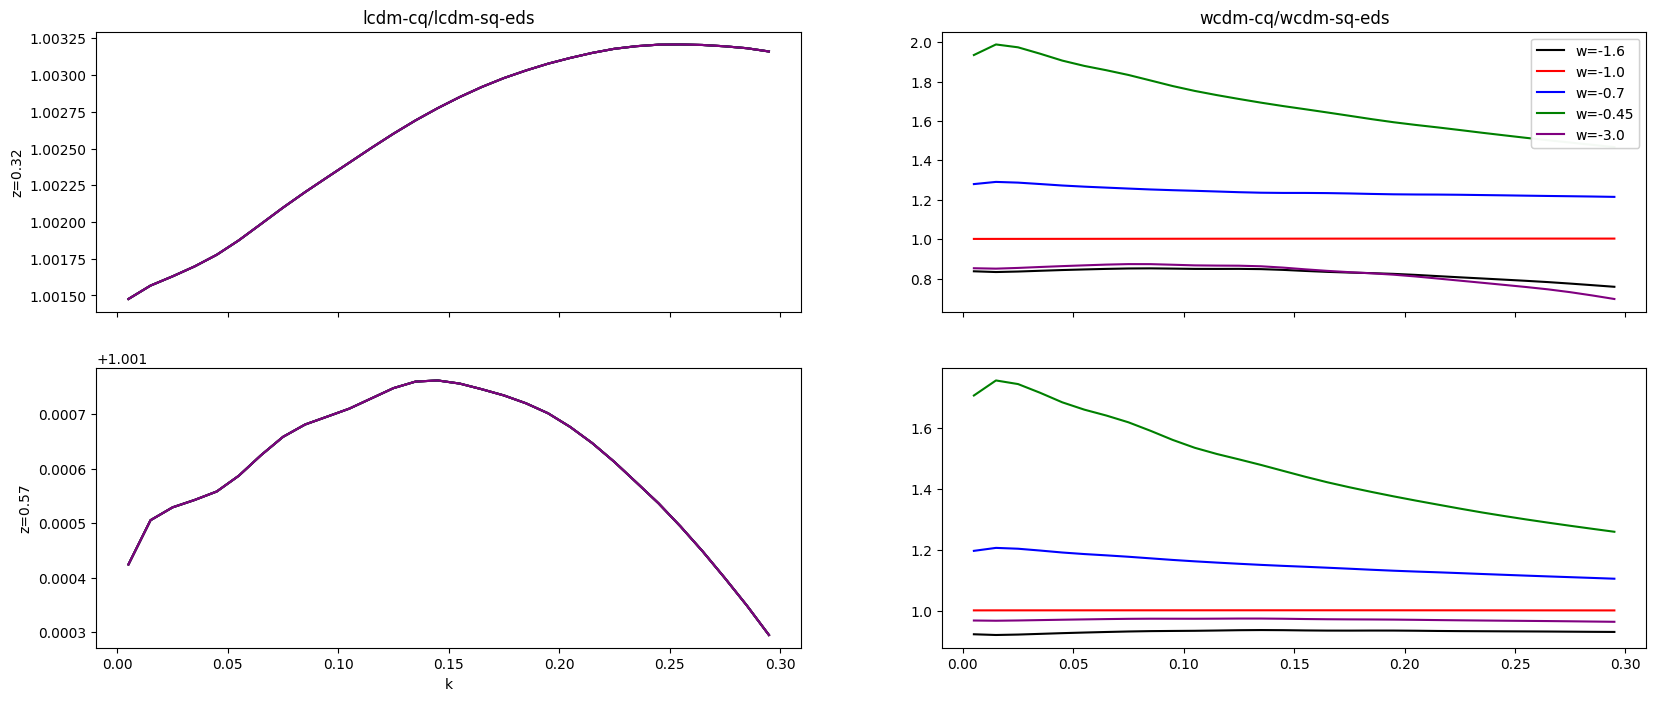

In [12]:
f,ax=plt.subplots(2,2,figsize=(20,8),sharex=True,sharey=False)
l=0


le1=[]
le2=[]
# wcdm
for iw in range(len(w)):
    for iz in range(len(zlist)):

        leg1 = ax[iz][0].plot(kd,(ex_pk_lcdm_cq_master[iz][l]/eds_pk_lcdm_master[iz][l]),color=color[iw])

        leg2 = ax[iz][1].plot(kd,(ex_pk_wcdm_cq_master[iw][iz][l]/eds_pk_wcdm_master[iw][iz][l]),color=color[iw])

        le2.append(leg2[0])
        
legbase = ax[0][1].legend([le2[i*len(zlist)] for i in range(len(w))],['w={}'.format(w[i]) for i in range(len(w))],loc=1,handlelength=2)
ax[0][1].add_artist(legbase)


# legbase = ax[0][0].legend([le1[0],le2[0]],['exact', 'eds'],loc=2)
# ax[0][0].add_artist(legbase)


# legbase = ax[0][1].legend([le1[0],le2[0]],['exact', 'eds'],loc=2)
# ax[0][1].add_artist(legbase)


ax[0][0].set_title('lcdm-cq/lcdm-sq-eds')
ax[0][1].set_title('wcdm-cq/wcdm-sq-eds')


ax[0][0].set_ylabel('z={}'.format(zlist[0]))
ax[1][0].set_ylabel('z={}'.format(zlist[1]))

ax[1][0].set_xlabel('k')

#f.suptitle('numerical greenfunction vs pybird_master')

### fplus and D in GF

In [13]:
M.scale_independent_growth_factor?

Object `M.scale_independent_growth_factor` not found.


In [14]:
from pybird_master.greenfunction import GreenFunction

z=0.32
ww = np.linspace(-2,-0.1,15)
cD_arr = np.zeros_like(ww)
cf_arr = np.zeros_like(ww)

sqD_arr = np.zeros_like(ww)
sqf_arr = np.zeros_like(ww)

cqD_arr = np.zeros_like(ww)
cqf_arr = np.zeros_like(ww)
for i in range(len(ww)):
    M,_,_,Dz,cf_arr[i] = get_cosmo_at_z(z,ww[i],0)
    _,_,_,D5,_ = get_cosmo_at_z(5,ww[i],0)
    cD_arr[i]=Dz/D5
    
    Omega0_m = M.Omega0_m()
    sqGF = GreenFunction(Omega0_m,w=ww[i],quintessence=False)
    sqf_arr[i]=sqGF.fplus(1/(1+z))
    sqD_arr[i]=sqGF.D(1/(1+z))/sqGF.D(1/(1+5))

    cqGF = GreenFunction(Omega0_m,w=ww[i],quintessence=True)
    cqf_arr[i]=cqGF.fplus(1/(1+z))
    cqD_arr[i]=cqGF.D(1/(1+z))/cqGF.D(1/(1+5))


Text(0.5, 0.98, 'ratio plot between GreenFunction and CLASS for fplus and D')

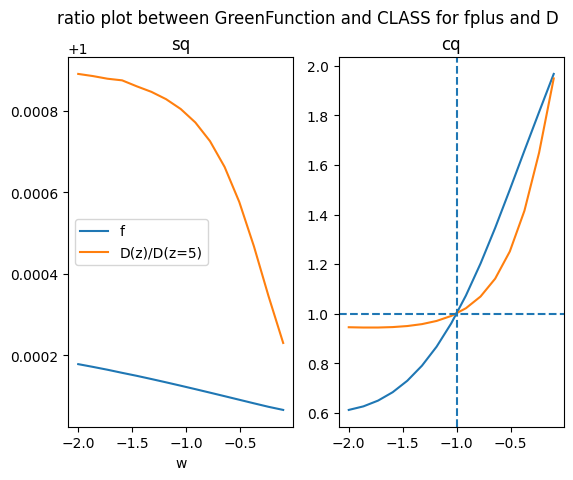

In [15]:
f,ax=plt.subplots(1,2)
ax[0].plot(ww,sqf_arr/cf_arr,label='f')
ax[0].plot(ww,sqD_arr/cD_arr,label='D(z)/D(z=5)')

ax[1].plot(ww,cqf_arr/cf_arr)
ax[1].plot(ww,cqD_arr/cD_arr)

ax[0].legend()
ax[0].set_xlabel('w')
ax[0].set_title('sq')
ax[1].set_title('cq')

ax[1].axhline(1,linestyle='--')
ax[1].axvline(-1,linestyle='--')

f.suptitle('ratio plot between GreenFunction and CLASS for fplus and D')

### error test

In [16]:
ex_pk_wcdm_master = [[get_spectrum(ps_master,zlist[i],bestbias,test_master=True,w0_fld=iw,Eds=False,with_quintessence=False) for i in range(len(zlist))] for iw in w]

ex_pk_lcdm_cq = [get_spectrum(ps_master,zlist[i],bestbias,test_master=False,w0_fld=-1.,Eds=False,with_quintessence=True) for i in range(len(zlist))]
ex_pk_wcdm_cq = [[get_spectrum(ps_master,zlist[i],bestbias,test_master=False,w0_fld=iw,Eds=False,with_quintessence=True) for i in range(len(zlist))] for iw in w]

eds_pk_wcdm = [[get_spectrum(ps_master,zlist[i],bestbias,test_master=False,w0_fld=iw,Eds=True,with_quintessence=False) for i in range(len(zlist))] for iw in w]
ex_pk_wcdm = [[get_spectrum(ps_master,zlist[i],bestbias,test_master=False,w0_fld=iw,Eds=False,with_quintessence=False) for i in range(len(zlist))] for iw in w]


/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. 

Text(0.5, 0.98, 'numerical greenfunction vs pybird_master')

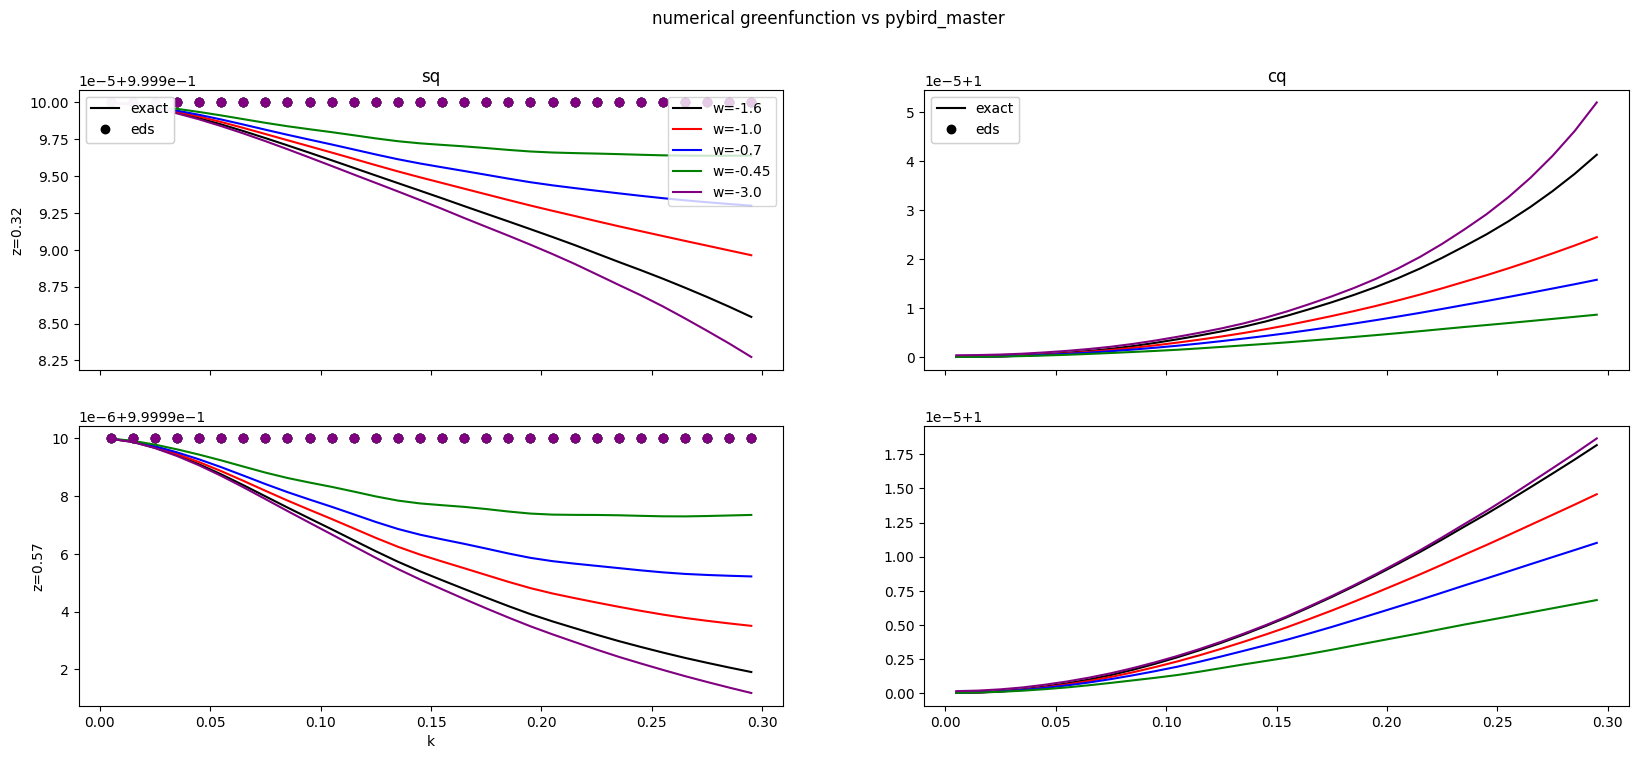

In [17]:
f,ax=plt.subplots(2,2,figsize=(20,8),sharex=True,sharey=False)
l=0

le1=[]
le2=[]
# wcdm
for iw in range(len(w)):
    for iz in range(len(zlist)):
        
        leg1 = ax[iz][0].plot(kd,(ex_pk_wcdm[iw][iz][l]/ex_pk_wcdm_master[iw][iz][l]),color=color[iw])
        leg2 = ax[iz][0].plot(kd,(eds_pk_wcdm[iw][iz][l]/eds_pk_wcdm_master[iw][iz][l]),'o',color=color[iw])

        ax[iz][1].plot(kd,(ex_pk_wcdm_cq[iw][iz][l]/ex_pk_wcdm_cq_master[iw][iz][l]),color=color[iw],label='w={}'.format(w[iw]))

        le1.append(leg1[0])
        le2.append(leg2[0])
        
legbase = ax[0][0].legend([le1[i*len(zlist)] for i in range(len(w))],['w={}'.format(w[i]) for i in range(len(w))],loc=1,handlelength=2)
ax[0][0].add_artist(legbase)


legbase = ax[0][0].legend([le1[0],le2[0]],['exact', 'eds'],loc=2)
ax[0][0].add_artist(legbase)


legbase = ax[0][1].legend([le1[0],le2[0]],['exact', 'eds'],loc=2)
ax[0][1].add_artist(legbase)


ax[0][0].set_title('sq')
ax[0][1].set_title('cq')


ax[0][0].set_ylabel('z={}'.format(zlist[0]))
ax[1][0].set_ylabel('z={}'.format(zlist[1]))

ax[1][0].set_xlabel('k')

f.suptitle('numerical greenfunction vs pybird_master')

# Exact/eds

## powerspectrum

In [18]:

eds_pk_w0wa = [[[get_spectrum(ps_master,zlist[i],bestbias,test_master=False,w0_fld=iw0,wa_fld=iwa,Eds=True,with_quintessence=False) for i in range(len(zlist))] for iwa in wa] for iw0 in w0]
ex_pk_w0wa = [[[get_spectrum(ps_master,zlist[i],bestbias,test_master=False,w0_fld=iw0,wa_fld=iwa,Eds=False,with_quintessence=False) for i in range(len(zlist))] for iwa in wa] for iw0 in w0]




/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. 

Text(0.5, 0.98, 'PowerSpectrum: ratio plot of exact_time and eds for wcdm(left) and w0wa(right)')

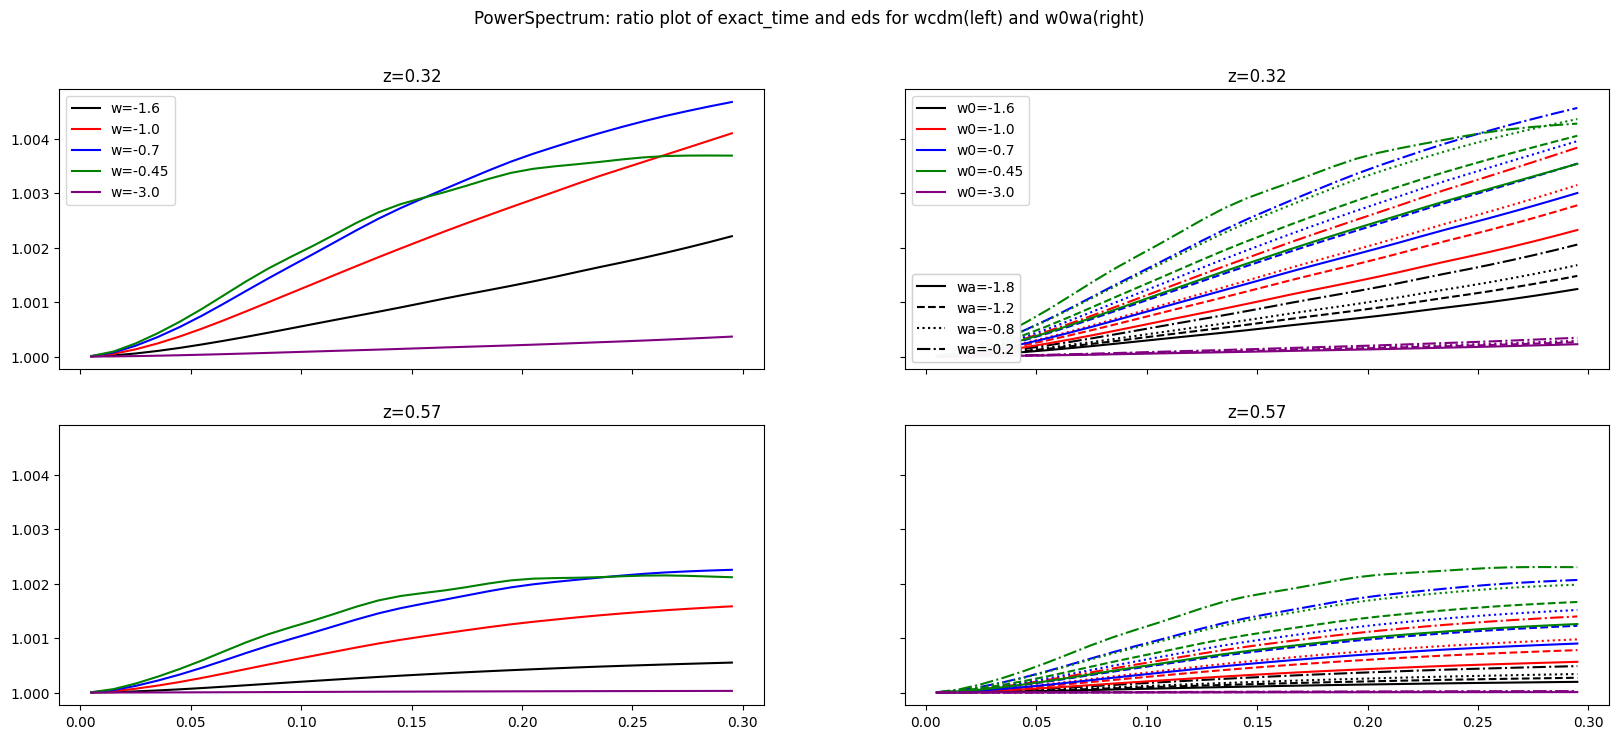

In [19]:


f,ax=plt.subplots(2,2,figsize=(20,8),sharex=True,sharey=True)
l=0

# wcdm
for iw in range(len(w)):
    for iz in range(len(zlist)):
        ax[iz][0].plot(kd,(ex_pk_wcdm[iw][iz][l]/eds_pk_wcdm[iw][iz][l]),color=color[iw],label='w={}'.format(w[iw]))

        ax[iz][0].set_title('z={:.2f}'.format(zlist[iz]))


ax[0][0].legend()


# w0wa
linestyle=['-','--',':','-.']
line=[]
for iw0 in range(len(w0)):
    for iwa in range(len(wa)):
        for iz in range(len(zlist)):
            li = ax[iz][1].plot(kd,(ex_pk_w0wa[iw0][iwa][iz][l]/eds_pk_w0wa[iw0][iwa][iz][l]),color=color[iw0],linestyle=linestyle[iwa],label='w0={},wa={}'.format(w0[iw0],wa[iwa]))
            line.append(li[0])

ax[0][1].set_title('z={:.2f}'.format(zlist[0]))
ax[1][1].set_title('z={:.2f}'.format(zlist[1]))


legbase = ax[0][1].legend([line[i*len(wa)*len(zlist)] for i in range(len(w0))],['w0={}'.format(w0[i]) for i in range(len(w0))],loc=2)
ax[0][1].add_artist(legbase)


legbase = ax[0][1].legend([line[2*i] for i in range(len(wa))],['wa={}'.format(wa[i]) for i in range(len(wa))],loc=3,handlelength=2)
ax[0][1].add_artist(legbase)


f.suptitle('PowerSpectrum: ratio plot of exact_time and eds for wcdm(left) and w0wa(right)')

# cq vs sq

In [20]:
ex_pk_w0wa_cq = [[[get_spectrum(ps_master,zlist[i],bestbias,test_master=False,w0_fld=iw0,wa_fld=iwa,Eds=False,with_quintessence=True) for i in range(len(zlist))] for iwa in wa] for iw0 in w0]


/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. 

In [21]:
ex_pk_w0wa_cq[0][0][0].shape

(2, 30)

Text(0.5, 0.98, 'PowerSpectrum: wcdm-cq/wcdm-sq(left) and w0wa-cq/w0wa-sq(right)')

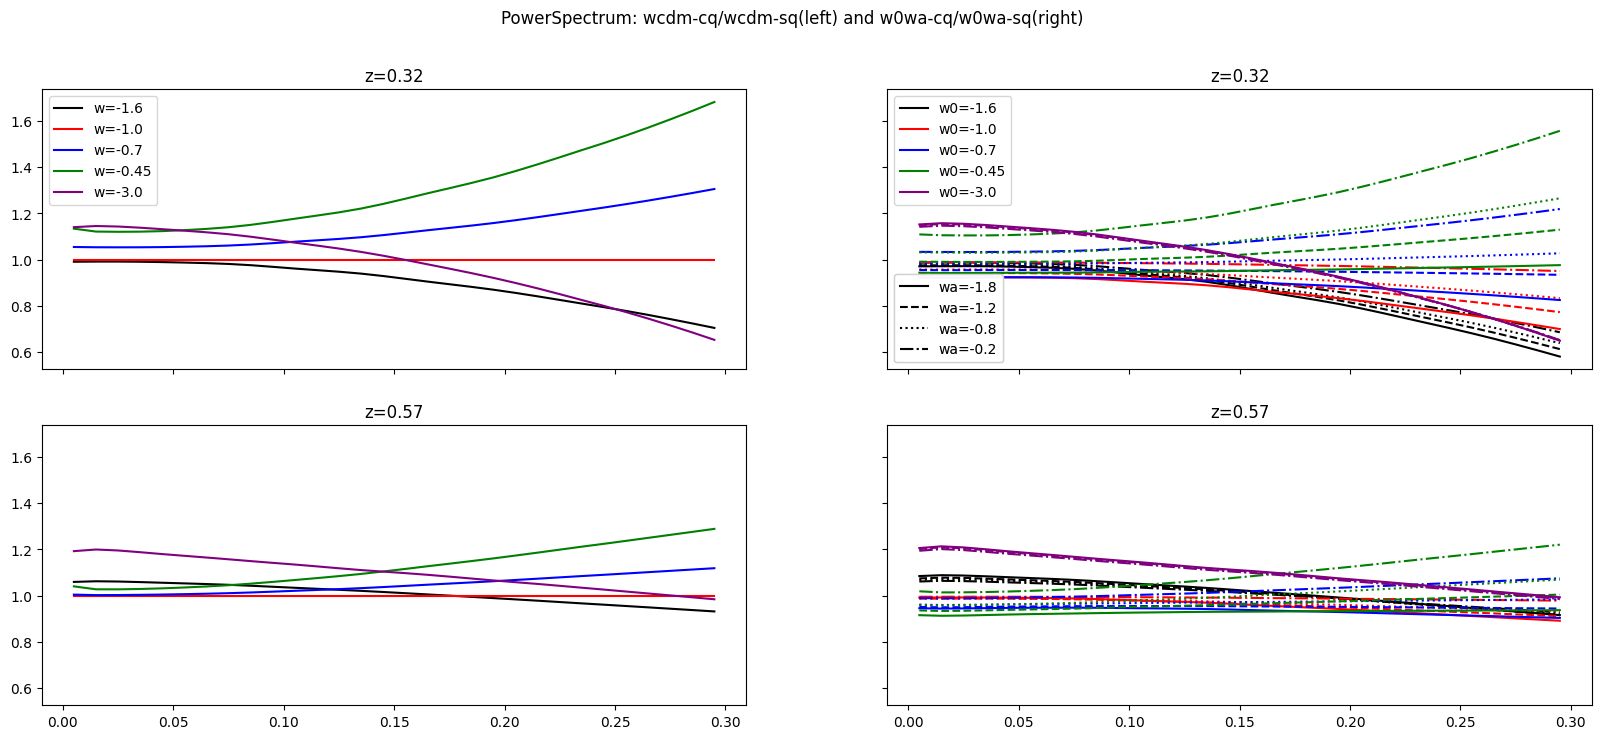

In [22]:


f,ax=plt.subplots(2,2,figsize=(20,8),sharex=True,sharey=True)
l=0

# wcdm
for iw in range(len(w)):
    for iz in range(len(zlist)):
        ax[iz][0].plot(kd,(ex_pk_wcdm_cq[iw][iz][l]/ex_pk_lcdm_cq[iz][l]),color=color[iw],label='w={}'.format(w[iw]))

        ax[iz][0].set_title('z={:.2f}'.format(zlist[iz]))


ax[0][0].legend()


# w0wa
linestyle=['-','--',':','-.']
line=[]
for iw0 in range(len(w0)):
    for iwa in range(len(wa)):
        for iz in range(len(zlist)):
            li = ax[iz][1].plot(kd,(ex_pk_w0wa_cq[iw0][iwa][iz][l]/ex_pk_lcdm_cq[iz][l]),color=color[iw0],linestyle=linestyle[iwa],label='w0={},wa={}'.format(w0[iw0],wa[iwa]))
            line.append(li[0])

ax[0][1].set_title('z={:.2f}'.format(zlist[0]))
ax[1][1].set_title('z={:.2f}'.format(zlist[1]))


legbase = ax[0][1].legend([line[i*len(wa)*len(zlist)] for i in range(len(w0))],['w0={}'.format(w0[i]) for i in range(len(w0))],loc=2)
ax[0][1].add_artist(legbase)


legbase = ax[0][1].legend([line[2*i] for i in range(len(wa))],['wa={}'.format(wa[i]) for i in range(len(wa))],loc=3,handlelength=2)
ax[0][1].add_artist(legbase)


f.suptitle('PowerSpectrum: wcdm-cq/wcdm-sq(left) and w0wa-cq/w0wa-sq(right)')

# cq vs eds

Text(0.5, 0.98, 'PowerSpectrum: wcdm-cq/wcdm-eds(left) and w0wa-cq/w0wa-eds(right)')

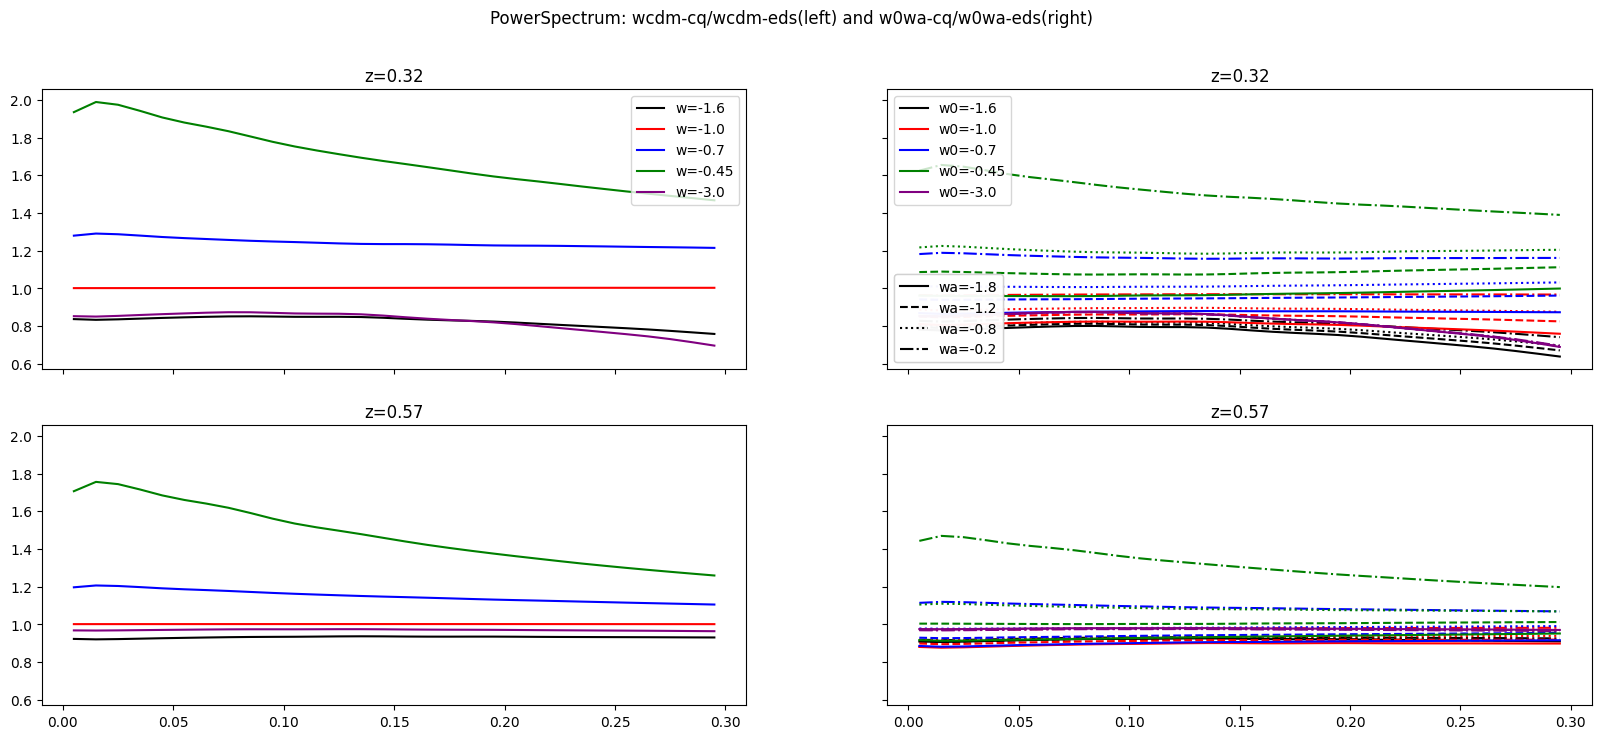

In [23]:


f,ax=plt.subplots(2,2,figsize=(20,8),sharex=True,sharey=True)
l=0

# wcdm
for iw in range(len(w)):
    for iz in range(len(zlist)):
        ax[iz][0].plot(kd,(ex_pk_wcdm_cq[iw][iz][l]/eds_pk_wcdm[iw][iz][l]),color=color[iw],label='w={}'.format(w[iw]))

        ax[iz][0].set_title('z={:.2f}'.format(zlist[iz]))


ax[0][0].legend()


# w0wa
linestyle=['-','--',':','-.']
line=[]
for iw0 in range(len(w0)):
    for iwa in range(len(wa)):
        for iz in range(len(zlist)):
            li = ax[iz][1].plot(kd,(ex_pk_w0wa_cq[iw0][iwa][iz][l]/eds_pk_w0wa[iw0][iwa][iz][l]),color=color[iw0],linestyle=linestyle[iwa],label='w0={},wa={}'.format(w0[iw0],wa[iwa]))
            line.append(li[0])

ax[0][1].set_title('z={:.2f}'.format(zlist[0]))
ax[1][1].set_title('z={:.2f}'.format(zlist[1]))


legbase = ax[0][1].legend([line[i*len(wa)*len(zlist)] for i in range(len(w0))],['w0={}'.format(w0[i]) for i in range(len(w0))],loc=2)
ax[0][1].add_artist(legbase)


legbase = ax[0][1].legend([line[2*i] for i in range(len(wa))],['wa={}'.format(wa[i]) for i in range(len(wa))],loc=3,handlelength=2)
ax[0][1].add_artist(legbase)


f.suptitle('PowerSpectrum: wcdm-cq/wcdm-eds(left) and w0wa-cq/w0wa-eds(right)')